In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [2]:
dados = pd.read_excel(r'D:\estudos\cursos_projetos_ciencia_dados\ida_extra_renovacao\5_modelagem_e_risco_de_credito\projeto\dados\yochi_base .xlsx')
dados.head()

,BAD,LOAN,MORTDUE,VALUE,REASON,JOB,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
0,1,1100,25860.0,39025.0,HomeImp,Other,10.5,0.0,0.0,94.366667,1.0,9.0,NaN
1,1,1300,70053.0,68400.0,HomeImp,Other,7.0,0.0,2.0,121.833333,0.0,14.0,NaN
2,1,1500,13500.0,16700.0,HomeImp,Other,4.0,0.0,0.0,149.466667,1.0,10.0,NaN
3,1,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,1700,97800.0,112000.0,HomeImp,Office,3.0,0.0,0.0,93.333333,0.0,14.0,NaN


In [3]:
dados.shape

(5960, 13)

In [4]:
dados.info()

<class 'pandas.DataFrame'>
RangeIndex: 5960 entries, 0 to 5959
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   BAD      5960 non-null   int64  
 1   LOAN     5960 non-null   int64  
 2   MORTDUE  5442 non-null   float64
 3   VALUE    5848 non-null   float64
 4   REASON   5708 non-null   str    
 5   JOB      5681 non-null   str    
 6   YOJ      5445 non-null   float64
 7   DEROG    5252 non-null   float64
 8   DELINQ   5380 non-null   float64
 9   CLAGE    5652 non-null   float64
 10  NINQ     5450 non-null   float64
 11  CLNO     5738 non-null   float64
 12  DEBTINC  4693 non-null   float64
dtypes: float64(9), int64(2), str(2)
memory usage: 605.4 KB


In [5]:
dados.describe()

,BAD,LOAN,MORTDUE,VALUE,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
count,5960.000000,5960.000000,5442.000000,5848.000000,5445.000000,5252.000000,5380.000000,5652.000000,5450.000000,5738.000000,4693.000000
mean,0.199497,18607.969799,73760.817200,101776.048741,8.922268,0.254570,0.449442,179.766275,1.186055,21.296096,33.779915
std,0.399656,11207.480417,44457.609458,57385.775334,7.573982,0.846047,1.127266,85.810092,1.728675,10.138933,8.601746
min,0.000000,1100.000000,2063.000000,8000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.524499
25%,0.000000,11100.000000,46276.000000,66075.500000,3.000000,0.000000,0.000000,115.116702,0.000000,15.000000,29.140031
50%,0.000000,16300.000000,65019.000000,89235.500000,7.000000,0.000000,0.000000,173.466667,1.000000,20.000000,34.818262
75%,0.000000,23300.000000,91488.000000,119824.250000,13.000000,0.000000,0.000000,231.562278,2.000000,26.000000,39.003141
max,1.000000,89900.000000,399550.000000,855909.000000,41.000000,10.000000,15.000000,1168.233561,17.000000,71.000000,203.312149


Ja deu pra ver que o target é desbalanceado o que é comum em contexto de credito, será experimentado modelaagem normal e com tecnica de balanceamento

In [6]:
dados.isnull().sum().sort_values()

BAD           0
LOAN          0
VALUE       112
CLNO        222
REASON      252
JOB         279
CLAGE       308
NINQ        510
YOJ         515
MORTDUE     518
DELINQ      580
DEROG       708
DEBTINC    1267
dtype: int64

# Tratativas a ser feita com os missings
VALUE  - 112: poucos missings em relacao ao total de dados será experimentado media como tecnica de imput

CLNO   - 222: poucos missings em relacao ao total de dados será experimentado media como tecnica de imput  

REASON - 252: poucos missings em relacao ao total de dados será experimentado acresscentar categoria 'missing' como tecnica de imput

JOB    - 279: poucos missings em relacao ao total de dados será experimentado acresscentar categoria 'missing' como tecnica de imput

CLAGE  - 308: poucos missings em relacao ao total de dados será experimentado acresscentar categoria 'missing' como tecnica de imput

NINQ   - 510: missings significativos em relacao ao total será experimentado 0 como se nao tivesse nenhuma consulta de credito(o ideal é conversar com negocio pra ver se é isso mesmo)

YOJ    - 515: missings significativos em relacao ao total será experimentado 0 como se nao tivesse trabalho atualmente(o ideal é conversar com negocio pra ver se é isso mesmo)

MORTDUE- 518: missings significativos em relacao ao total de dados será experimentado media como tecnica de imput

DELINQ - 580: missings significativos em relacao ao total será experimentado 0 como se nao tivesse linha de credito inadimplente(o ideal é conversar com negocio pra ver se é isso mesmo)

DEROG  - 708: missings significativos em relacao ao total será experimentado 0 como se nao tivesse relatorio depreciativo(o ideal é conversar com negocio pra ver se é isso mesmo)

DEBTINC-1267: missings significativos em relacao ao total será experimentado 0 como se nao tivesse receita/divida(o ideal é conversar com negocio pra ver se é isso mesmo)

In [7]:
dados.groupby('REASON')['BAD'].count()
# ver a outra categorica tambem e ver se consigo colocar em grafco de barras


REASON
DebtCon    3928
HomeImp    1780
Name: BAD, dtype: int64

In [8]:
var_num = ["LOAN",	"MORTDUE",	"VALUE",	"YOJ",	"DEROG",	"DELINQ",	"CLAGE",	"NINQ",	"CLNO",	"DEBTINC"]


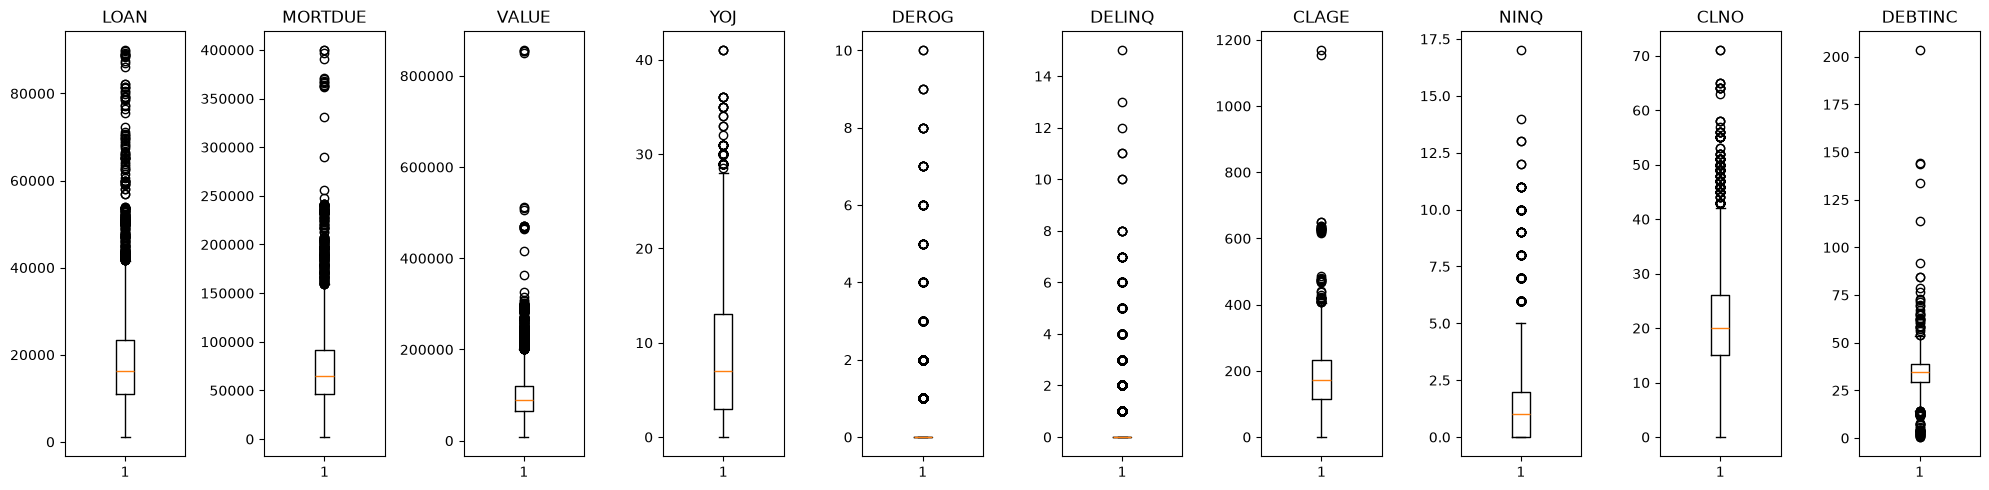

In [9]:
def boxs_plots(variaveis):
    # cria graficos(boxplot) para cada variaveil numerica passadas no argumento:
    n_var = len(variaveis)
    n_cols = 10
    n_linhas = math.ceil(n_var / n_cols)

    fig, ax = plt.subplots(n_linhas, n_cols, figsize=(20, 5*n_linhas))

    # transforma em vetor caso tenha apenas 1 linha
    ax = ax.flatten()

    for i, var in enumerate(variaveis):
        ax[i].boxplot(dados[var].dropna())
        ax[i].set_title(var)

    # remove gráficos vazios
    for j in range(i + 1, len(ax)):
        fig.delaxes(ax[j])

    plt.tight_layout()
    plt.show()


boxs_plots(var_num)

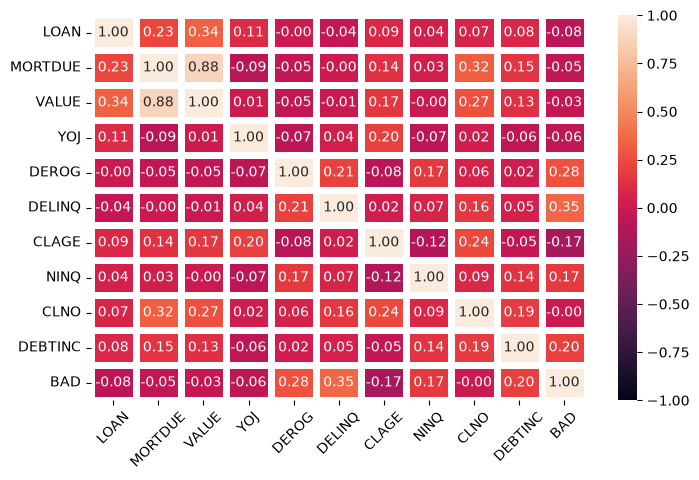

In [10]:
var_num_targ = var_num.copy()
var_num_targ.append('BAD')

coef_corr_ = dados[var_num_targ].corr()

plt.figure(figsize=(8,5))

sns.heatmap(coef_corr_,
            annot=True,
            vmin=-1,
            vmax=1,
            fmt='.2f',
            linewidths=5
            )

plt.xticks(rotation=45)
plt.show()


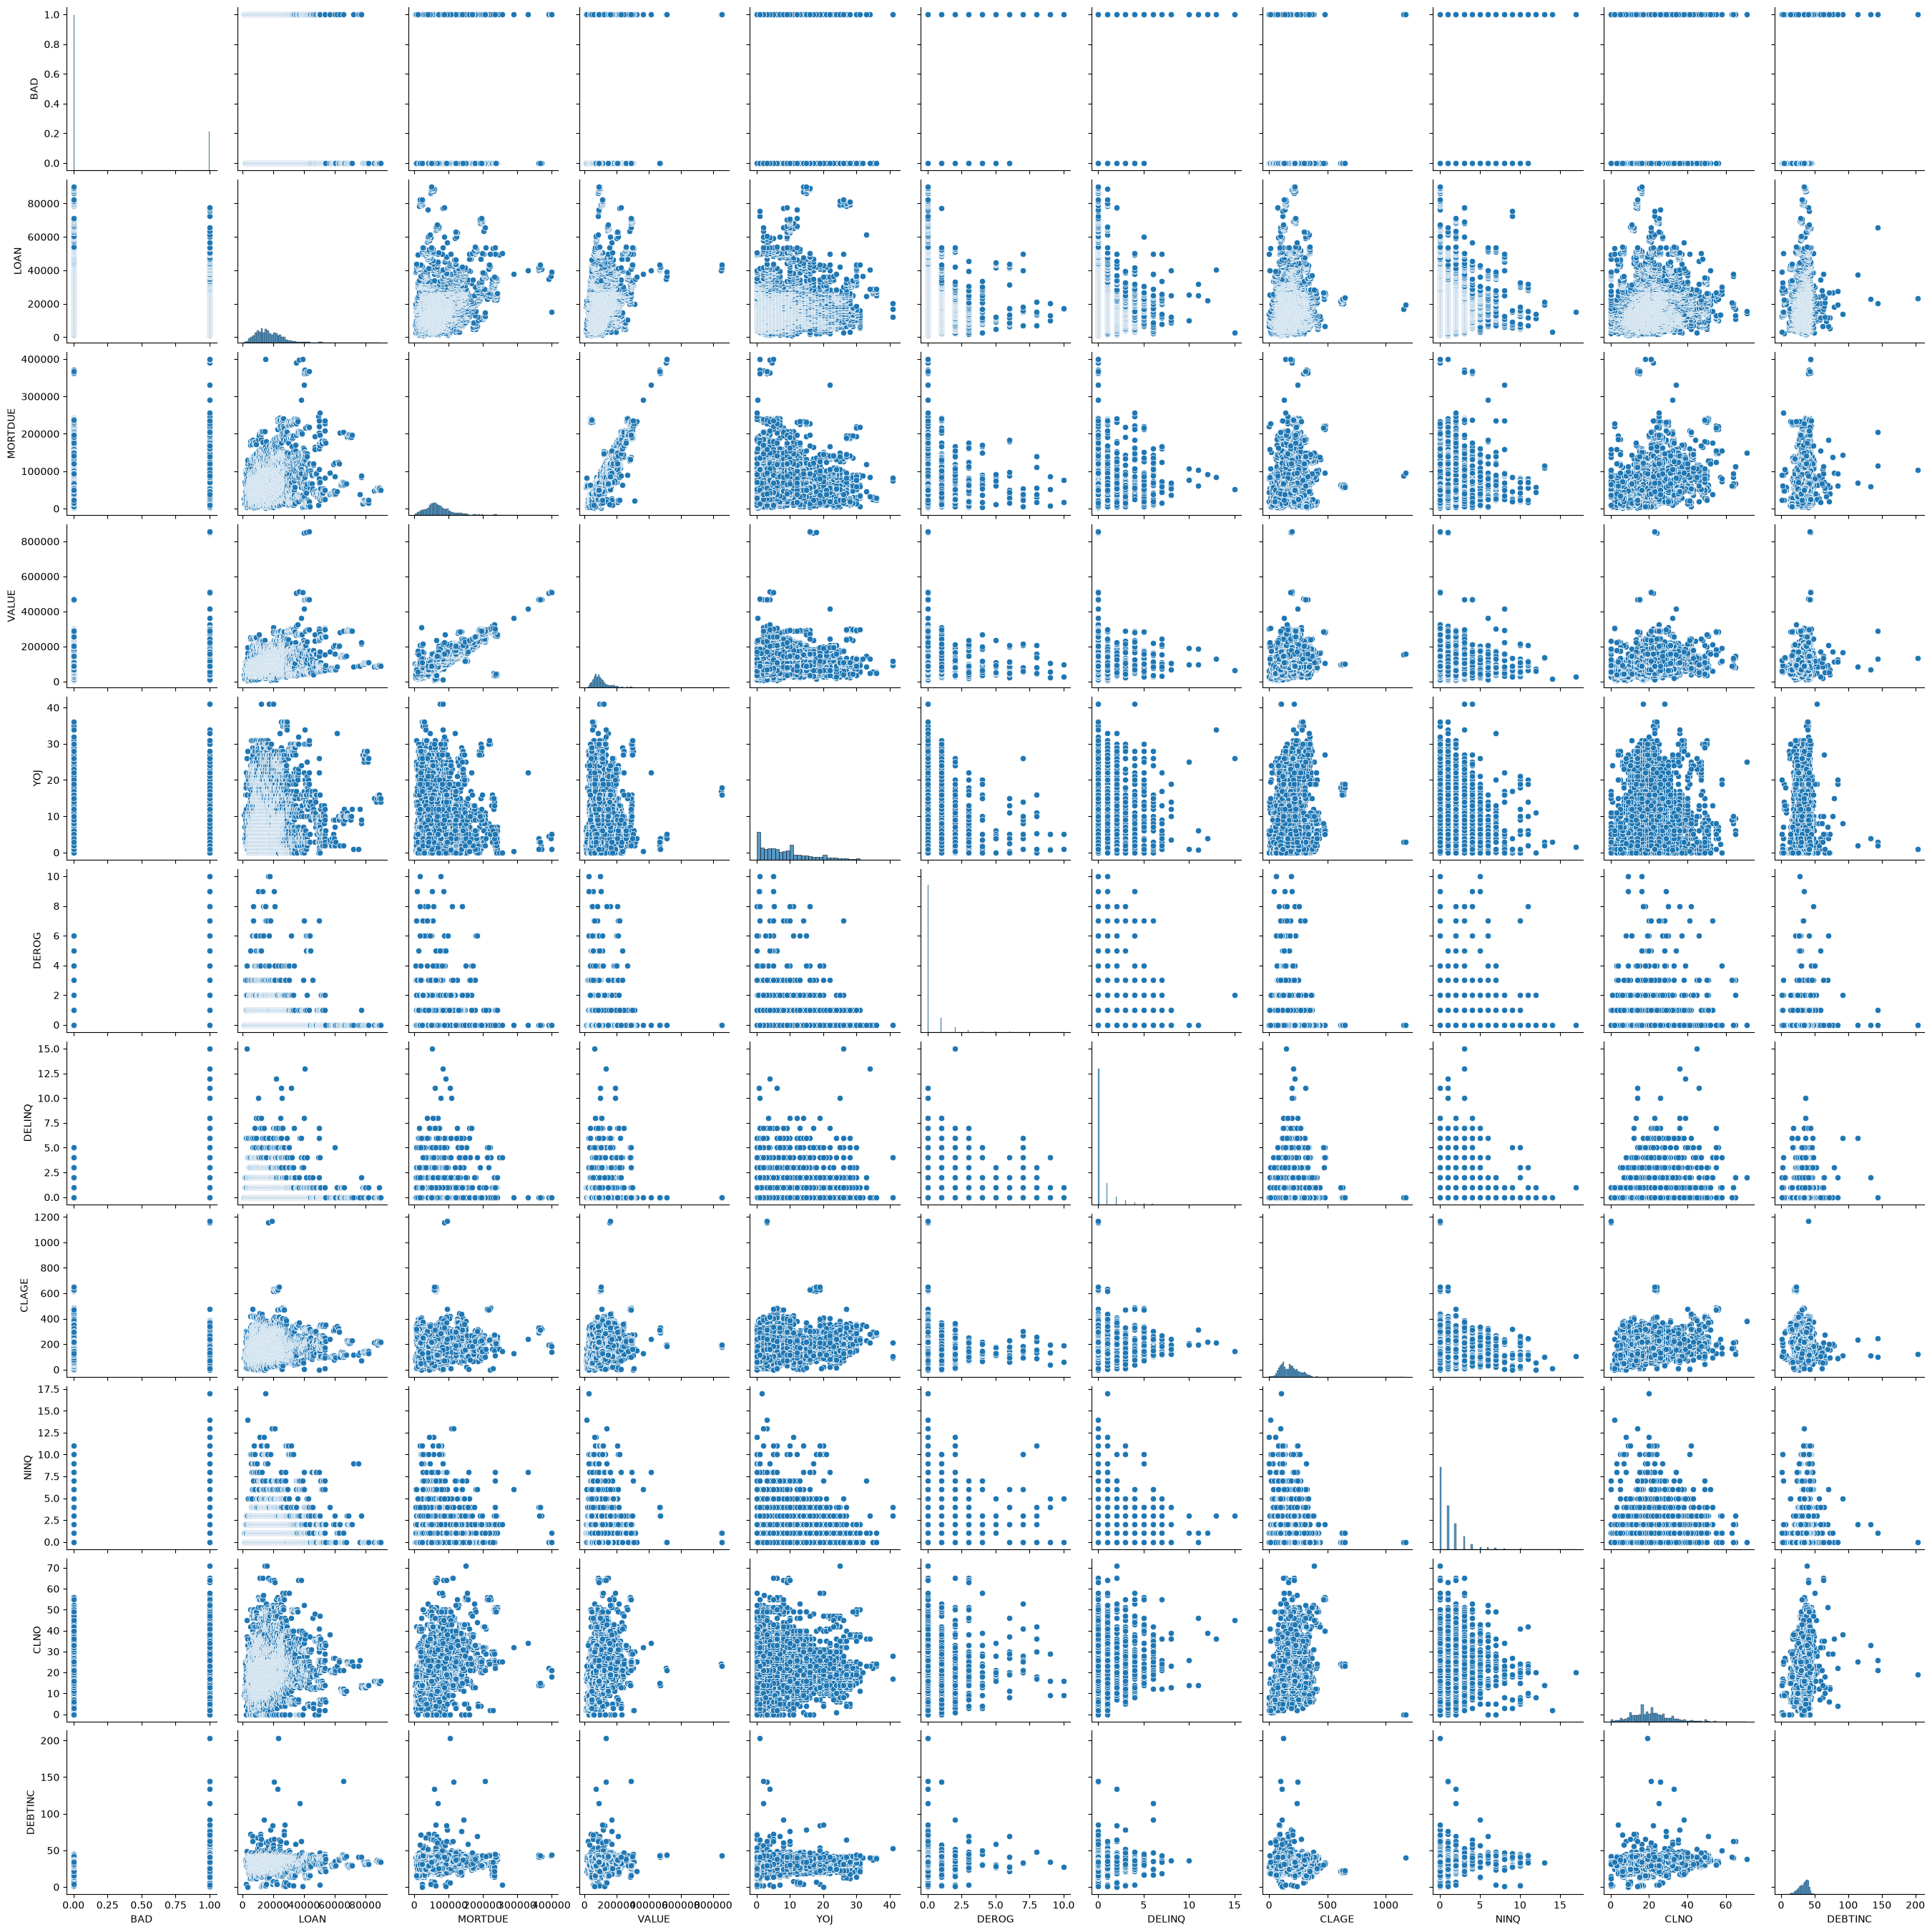

In [11]:
sns.pairplot(dados)
plt.show()

observando a matriz de correlacao e o pairplot podemos concluir que existe alguma correlacao tanto entre variaveis(multicolinearidade) quanto entre variaveis e target
esses graficos de dispersao de independentes com a target nao chega a ser significativamente linear, entao arvores talvez lide melhor na classificacao em termos de precisao